# Global imports

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import scipy.stats as stats
from scipy.stats import pearsonr, kendalltau, spearmanr

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from textwrap import wrap
from joblib import Parallel, delayed
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import set_link_color_palette, dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import random
from scipy.optimize import linear_sum_assignment
import gseapy as gp


In [ ]:
from statsmodels.stats.multitest import multipletests 
gna_prefix = '../GeneExpNetworkAnalysis/'


# Analysis

## Preprocessing

In [ ]:
ad_gwas_df = pd.read_table(gna_prefix+'PD_MONDO_0004975_associations_export.tsv')
ad_gwas_df.replace({'-': float('nan')}, inplace=True)
ad_genes = ad_gwas_df.mappedGenes.dropna().unique()
ad_genes = []
for gene in [gene.split(',') for gene in ad_gwas_df[ad_gwas_df.author=='Bellenguez C'].mappedGenes.dropna().unique()]:     
    ad_genes.extend(gene)
ad_genes = list(set(ad_genes))
ad_genes.append('APOE')
prefix_adata = '../adatas/'
adata_ros = sc.read_h5ad(prefix_adata+'mathys19_pp_filtered_June21.h5ad')
ad_gwas_genes = set(adata_ros.var.index.values.tolist()).intersection(set(ad_genes))
ad_ge_df = pd.DataFrame(data=adata_ros.X.toarray(), columns = adata_ros.var.index.to_list(), index = adata_ros.obs.id)

In [ ]:
ad_coi = ad_ge_df.columns
ad_ge_df['cell_type'] = adata_ros.obs.cell_type.values
ad_ge_df['diagnosis'] = adata_ros.obs.diagnosis.values

In [ ]:
ad_ge_df_d = ad_ge_df[ad_ge_df.diagnosis==1].copy()
ad_ge_df_d.drop(columns=['diagnosis'], inplace=True)
ad_ge_df_c = ad_ge_df[ad_ge_df.diagnosis==-1].copy()
ad_ge_df_c.drop(columns=['diagnosis'], inplace=True)
del(ad_ge_df)

In [ ]:
pd_gwas_df = pd.read_table(gna_prefix+'AD_MONDO_0005180_associations_export.tsv')
pd_gwas_df.replace({'-': float('nan')}, inplace=True)
pd_genes = pd_gwas_df.mappedGenes.dropna().unique()
common_gwas_genes = list(set(pd_genes).intersection(set(ad_genes)))
pd_genes = []
for gene in [gene.split(',') for gene in pd_gwas_df[pd_gwas_df.author=='Nalls MA'].mappedGenes.dropna().unique()]:     
    pd_genes.extend(gene)
pd_genes = list(set(pd_genes))
prefix_pd = '../PD/sc rna of dominergic neurons/DaN/'
adata_pd = sc.read_h5ad(prefix_adata+'kadata_pp_agematch_Oct31.h5ad')
genes_ros = sc.read_h5ad(prefix_adata+'mathys19_pp_filtered_June21.h5ad').var.index.unique()
adata_pd = adata_pd[:, adata_pd.var.index.isin(genes_ros)]
pd_gwas_genes = set(adata_pd.var.index.values.tolist()).intersection(set(pd_genes))
pd_ge_df = pd.DataFrame(data=adata_pd.X.toarray(), columns = adata_pd.var.index, index = adata_pd.obs.index)


In [ ]:
pd_coi = pd_ge_df.columns
pd_ge_df['cell_type'] = adata_pd.obs.cell_type.values
pd_ge_df['diagnosis'] = adata_pd.obs.diagnosis.values

In [ ]:
pd_ge_df = pd.DataFrame(data=adata_pd.X.toarray(), columns = adata_pd.var.index, index = adata_pd.obs.index)
pd_coi = pd_ge_df.columns
pd_ge_df['cell_type'] = adata_pd.obs.cell_type.values
pd_ge_df['diagnosis'] = adata_pd.obs.diagnosis.values

In [ ]:
pd_ge_df_d = pd_ge_df[pd_ge_df.diagnosis==1].copy()
pd_ge_df_d.drop(columns=['diagnosis'], inplace=True)
pd_ge_df_c = pd_ge_df[pd_ge_df.diagnosis==-1].copy()
pd_ge_df_c.drop(columns=['diagnosis'], inplace=True)
del(pd_ge_df)

In [ ]:
all_gois = list(ad_gwas_genes.union(pd_gwas_genes))

## Utils

In [ ]:
ct_map = {'Oligodendrocyte': 'Oli',
            'Excitatory neuron': 'Ex',
            'Inhibitory neuron': 'In',
            'Astrocyte': 'Ast',
            'Endothelial': 'Endo',
            'Microglia': 'Mic',
            'Macrophage': 'Macro',
            'SOX6': 'Sox6',
            'CALB1': 'Calb1',
            'Ependyma':'Epen',
            'OPC': 'Opc',
            'Pericyte': 'Per',
            }

In [ ]:
def do_and_save_corr(ge_df, goi, coi, corr_metric, disease, label):
    'Perform correlation of a given GWAS gene with all other genes and save corr statistic'
    print(goi, disease, label)
    def f(x, goi, coi, corr_metric):
        def g(y):
            return corr_metric(y, x[goi]).statistic
        return x[coi].apply(g, axis=0)
    try:
        agg_df = ge_df.groupby(['cell_type']).apply(f, goi,  coi, corr_metric).fillna(0)
        # agg_df.fillna(0, inplace=True)
        print(f'writing {disease}_agg_df_{goi}_{label}_{corr_metric.__name__}')
        agg_df.to_csv(gna_prefix+f'GeneCorrs/{disease}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv')
        del(agg_df)
        del(ge_df)
    except:
        print(f'skipping {disease} {goi}')


def do_all(goi, ad_ge_df_d, ad_ge_df_c, pd_ge_df_d, pd_ge_df_c, corr_metric):
    # do_and_save_corr(ad_ge_df_d, goi, list(set(ad_coi) - set([goi])), corr_metric, 'ad', 'disease')
    # do_and_save_corr(ad_ge_df_c, goi, list(set(ad_coi) - set([goi])), corr_metric, 'ad', 'control')
    do_and_save_corr(pd_ge_df_d, goi, list(set(pd_coi) - set([goi])), corr_metric, 'pd', 'disease')
    do_and_save_corr(pd_ge_df_c, goi, list(set(pd_coi) - set([goi])), corr_metric, 'pd', 'control')
    


In [ ]:
def do_and_save_corr_pval(ge_df, goi, coi, corr_metric, disease, label):
    print(goi, disease, label)
    def f(x, goi, coi, corr_metric):
        def g(y):
            return corr_metric(y, x[goi]).pvalue
        return x[coi].apply(g, axis=0)
    try:
        agg_df = ge_df.groupby(['cell_type']).apply(f, goi,  coi, corr_metric).fillna(0)
        print(f'writing {disease}_agg_df_{goi}_{label}_{corr_metric.__name__}_pval')
        agg_df.to_csv(gna_prefix+f'GeneCorrs/{disease}_agg_df_{goi}_{label}_{corr_metric.__name__}_pval.csv')
        del(agg_df)
        del(ge_df)
    except:
        print(f'skipping {disease} {goi}')


def do_all_pval(goi, ad_ge_df_d, ad_ge_df_c, pd_ge_df_d, pd_ge_df_c, corr_metric):
    # do_and_save_corr_pval(ad_ge_df_d, goi, list(set(ad_coi) - set([goi])), corr_metric, 'ad', 'disease')
    # do_and_save_corr_pval(ad_ge_df_c, goi, list(set(ad_coi) - set([goi])), corr_metric, 'ad', 'control')
    do_and_save_corr_pval(pd_ge_df_d, goi, list(set(pd_coi) - set([goi])), corr_metric, 'pd', 'disease')
    do_and_save_corr_pval(pd_ge_df_c, goi, list(set(pd_coi) - set([goi])), corr_metric, 'pd', 'control')
    


## Correlation AD PD

In [ ]:
all_gois = np.loadtxt(gna_prefix+'Genes of interest.csv', dtype=str)

In [ ]:
corr_metric = kendalltau

In [ ]:
def do_corr(df1_d, df2_d, df1_c, df2_c, disease1, disease2, corr_metric):
    '''get differential (between disease and control) co-expression (correlation)'''
    df1_melt_d = pd.melt(df1_d, id_vars='cell_type', var_name='gene', value_name=f'{corr_metric.__name__}_corr')
    df2_melt_d = pd.melt(df2_d, id_vars='cell_type', var_name='gene', value_name=f'{corr_metric.__name__}_corr')
    df1_melt_c = pd.melt(df1_c, id_vars='cell_type', var_name='gene', value_name=f'{corr_metric.__name__}_corr')
    df2_melt_c = pd.melt(df2_c, id_vars='cell_type', var_name='gene', value_name=f'{corr_metric.__name__}_corr')
    
    df1 = df1_melt_d.merge(df1_melt_c, on = ['cell_type', 'gene'], how = 'outer', suffixes=('_d', '_c'))
    df1[f'{corr_metric.__name__}_diff'] = df1[f'{corr_metric.__name__}_corr_d']  - df1[f'{corr_metric.__name__}_corr_c']
    df2 = df2_melt_d.merge(df2_melt_c, on = ['cell_type', 'gene'], how = 'outer', suffixes=('_d', '_c'))
    df2[f'{corr_metric.__name__}_diff'] = df2[f'{corr_metric.__name__}_corr_d']  - df2[f'{corr_metric.__name__}_corr_c']

    df_agg = df1.merge(df2, how='inner', on=['gene'], suffixes=[f'_{disease1}', f'_{disease2}'] )

    mtx = df_agg.groupby([f'cell_type_{disease1}', f'cell_type_{disease2}']).apply(lambda x: corr_metric(x[f'{corr_metric.__name__}_diff_{disease1}'], x[f'{corr_metric.__name__}_diff_{disease2}'])[0])
    mtx = mtx.to_frame(name = f'{corr_metric.__name__}_corr').reset_index()
    mtx[f'cell_type_{disease1}'] = mtx.cell_type_pd.replace(ct_map)
    return mtx

In [ ]:
def do_all_corrs(disease1, disease2, goi, label, corr_metric):
    '''Get differential co-expression for all GWAS genes'''
    try:
        label = 'disease'
        df1_d = pd.read_csv(gna_prefix+f'GeneCorrs/{disease1}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv')
        df2_d = pd.read_csv(gna_prefix+f'GeneCorrs/{disease2}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv')
        label = 'control'
        df1_c = pd.read_csv(gna_prefix+f'GeneCorrs/{disease1}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv')
        df2_c = pd.read_csv(gna_prefix+f'GeneCorrs/{disease2}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv')
        mtx = do_corr(df1_d, df2_d, df1_c, df2_c, disease1, disease2, corr_metric)
        return mtx
    except:
        print(f'skipping {goi} because the gene is not present in one of the diseases')
        return pd.DataFrame()
    
corr_diffs = Parallel(n_jobs=-1, verbose=10)(delayed(do_all_corrs)('pd', 'ad', goi, 'disease', corr_metric) for goi in all_gois)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


skipping TRIM40 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   16.4s
/opt/anaconda3/envs/scrnaseq/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   26.5s


skipping LINC00326 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   29.7s


...

[Parallel(n_jobs=-1)]: Done  78 tasks      | elapsed:  1.5min


skipping LINC00456 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 108 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 125 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:  2.8min


skipping DLG2 because the gene is not present in one of the diseases
skipping LZTS3 because the gene is not present in one of the diseases
skipping SMAD4 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done 175 out of 175 | elapsed:  3.4min finished


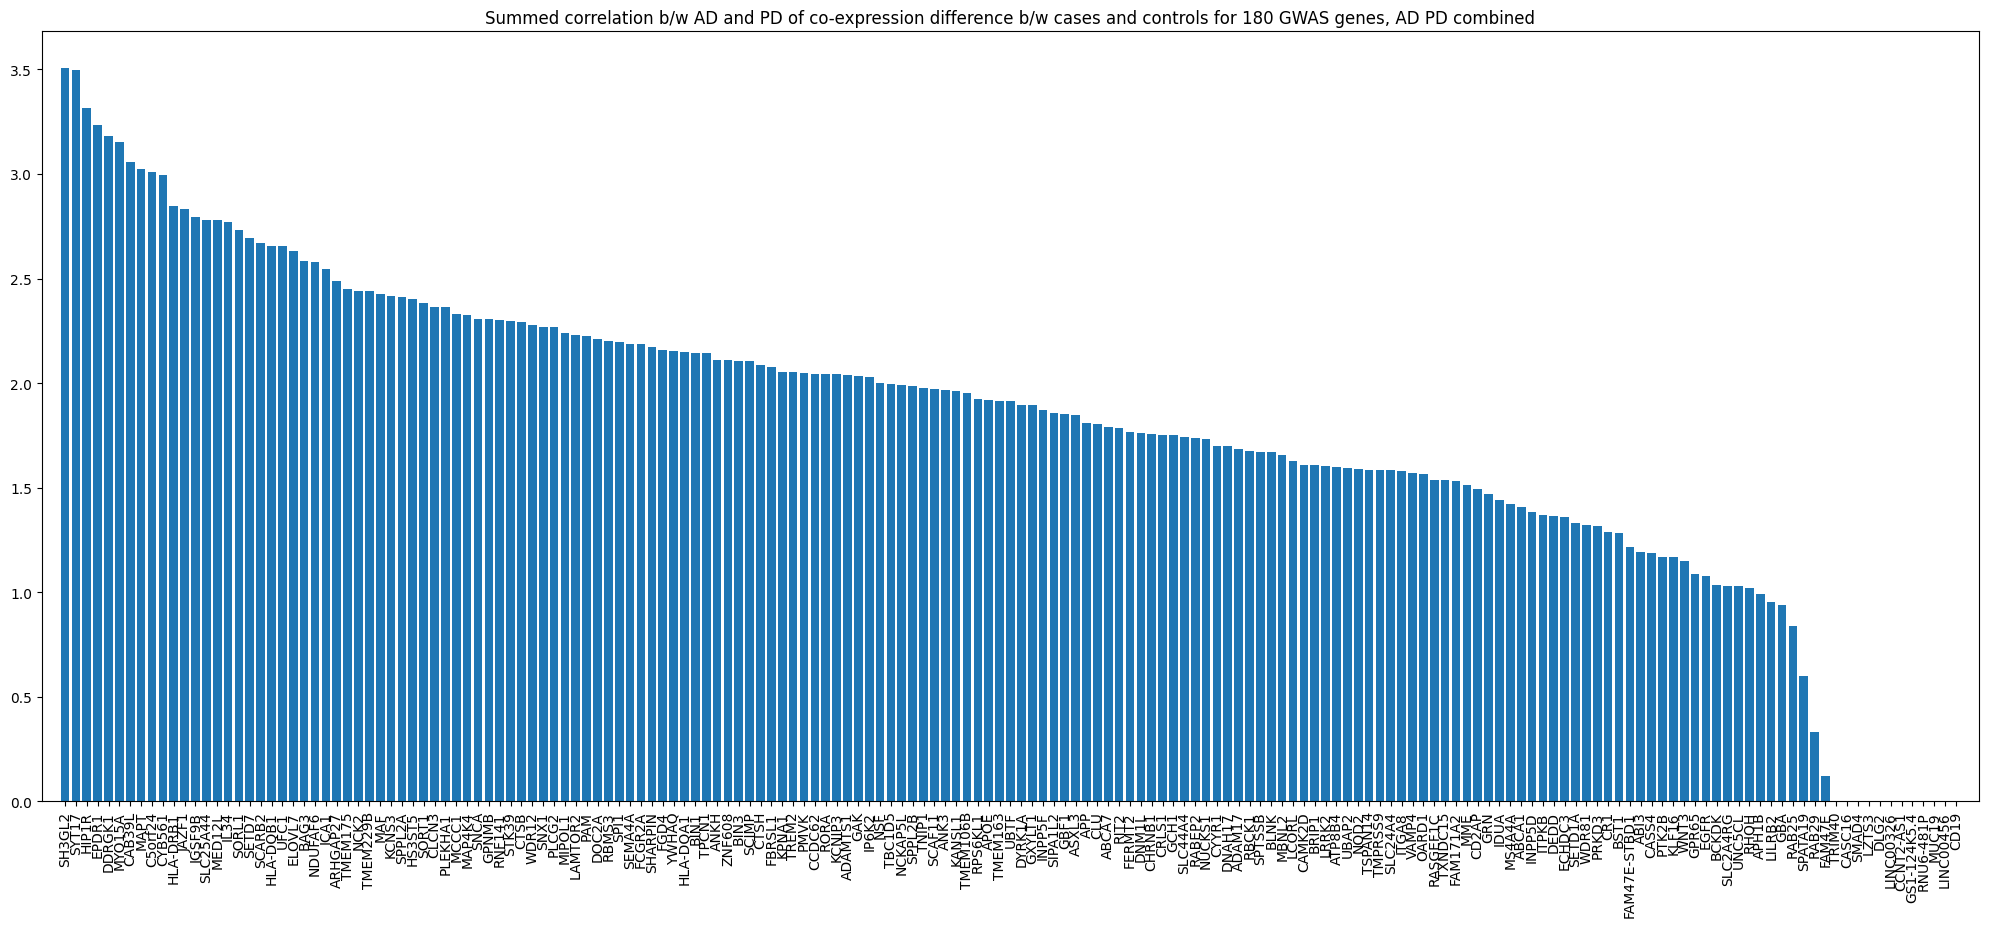

In [ ]:
corr_vals = [_df[f'{corr_metric.__name__}_corr'].abs().sum() if not _df.empty else 0 for _df in corr_diffs]
sort_idx = np.abs(np.array(corr_vals)).argsort()[::-1]

f, ax = plt.subplots(figsize=(25,10))
ax = plt.bar(np.array(list(all_gois))[sort_idx], np.array(corr_vals)[sort_idx])
_ = plt.xticks(rotation=90)
plt.title('Summed correlation b/w AD and PD of co-expression difference b/w cases and controls for 180 GWAS genes, AD PD combined')
plt.margins(x=0.01)

## Hierarchial clustering
Cluster DGCNs to analyze cell-type similarities between AD and PD

In [ ]:
def do_diff(df1_d, df2_d, df1_c, df2_c, disease1, disease2, corr_metric):
    df1_melt_d = pd.melt(df1_d, id_vars='cell_type', var_name='gene', value_name=f'{corr_metric.__name__}_corr')
    df2_melt_d = pd.melt(df2_d, id_vars='cell_type', var_name='gene', value_name=f'{corr_metric.__name__}_corr')
    df1_melt_c = pd.melt(df1_c, id_vars='cell_type', var_name='gene', value_name=f'{corr_metric.__name__}_corr')
    df2_melt_c = pd.melt(df2_c, id_vars='cell_type', var_name='gene', value_name=f'{corr_metric.__name__}_corr')
    
    df1 = df1_melt_d.merge(df1_melt_c, on = ['cell_type', 'gene'], how = 'outer', suffixes=('_d', '_c'))
    df1[f'{corr_metric.__name__}_diff'] = df1[f'{corr_metric.__name__}_corr_d'] - df1[f'{corr_metric.__name__}_corr_c']
    df1.drop(df1[df1.cell_type.isin(['Per', 'End', 'Macro', 'Epen'])].index, inplace=True)
    df1[f'cell_type'] = df1.cell_type.replace(ct_map)
    df1['cell_type'] = df1['cell_type'] + f'_{disease1}'

    df2 = df2_melt_d.merge(df2_melt_c, on = ['cell_type', 'gene'], how = 'outer', suffixes=('_d', '_c'))
    df2[f'{corr_metric.__name__}_diff'] = df2[f'{corr_metric.__name__}_corr_d'] - df2[f'{corr_metric.__name__}_corr_c']
    df2.drop(df2[df2.cell_type.isin(['Per', 'End', 'Macro', 'Epen'])].index, inplace=True)
    df2['cell_type'] = df2['cell_type'] + f'_{disease2}'
    
    df_agg = pd.concat([df1, df2])

    return df_agg

In [ ]:
def do_all_diffs(disease1, disease2, goi, label, corr_metric):
    try:
        label = 'disease'
        df1_d = pd.read_csv(gna_prefix+f'GeneCorrs/{disease1}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv')
        df2_d = pd.read_csv(gna_prefix+f'GeneCorrs/{disease2}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv')
        label = 'control'
        df1_c = pd.read_csv(gna_prefix+f'GeneCorrs/{disease1}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv')
        df2_c = pd.read_csv(gna_prefix+f'GeneCorrs/{disease2}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv')
        df_agg = do_diff(df1_d, df2_d, df1_c, df2_c, disease1, disease2, corr_metric)
        return df_agg
    except:
        print(f'skipping {goi} because the gene is not present in one of the diseases')
        return pd.DataFrame() #0
    
coexp_diffs = Parallel(n_jobs=-1, verbose=10)(delayed(do_all_diffs)('pd', 'ad', goi, 'disease', corr_metric) for goi in all_gois)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


skipping TRIM40 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   15.4s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   16.3s


skipping LINC00326 because the gene is not present in one of the diseases
skipping CCNT2-AS1 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   23.0s


...

[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 108 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 125 tasks      | elapsed:  1.5min


skipping DLG2 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:  1.7min


skipping LZTS3 because the gene is not present in one of the diseases
skipping SMAD4 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done 175 out of 175 | elapsed:  2.1min finished


In [ ]:
data_c = [coexp_diff[coexp_diff.gene.isin(set(ad_ge_df.columns).intersection(pd_ge_df.columns))].assign(gwasg=goi).pivot_table(index = ['gene', 'gwasg'], columns = ['cell_type'], values = 'kendalltau_diff').fillna(0) for coexp_diff, goi in zip(coexp_diffs, all_gois) if not coexp_diff.empty]
data_c = pd.concat(data_c)

In [ ]:
data_c.drop(columns = ['Macro_pd', 'Epen_pd'], inplace=True)

In [ ]:
linkage_data_c = linkage(data_c.T, method='average', metric='euclidean', optimal_ordering = True)  # July 12th, changed average to WARD

In [ ]:
import matplotlib as mpl


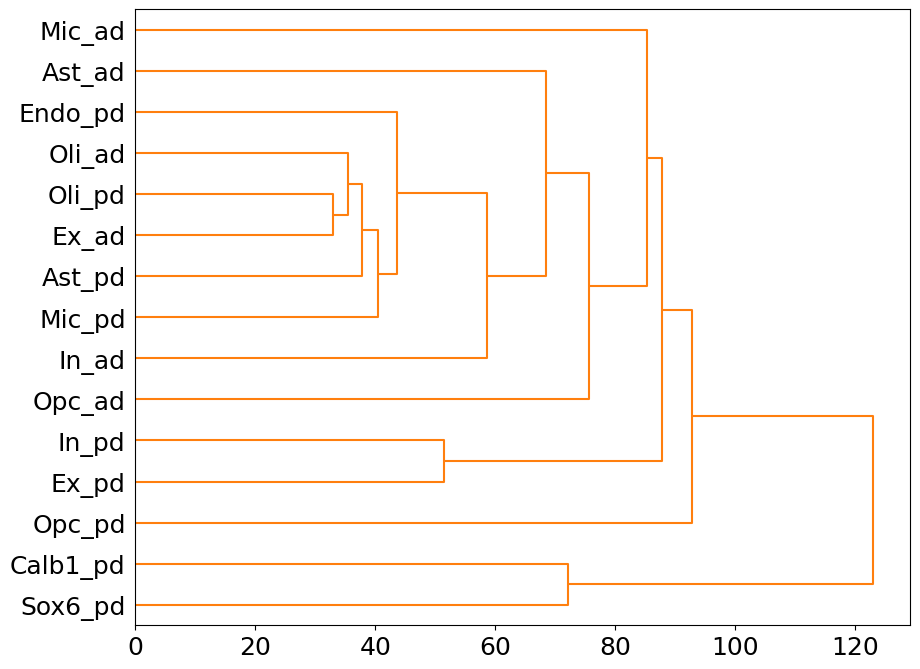

In [ ]:
f, ax_dc = plt.subplots(figsize=(10, 8))
_ = dendrogram(linkage_data_c, ax=ax_dc, labels=data_c.columns, orientation='right', color_threshold = 5000,)
ax_dc.tick_params(labelsize=18)

In [ ]:
plt.rcParams['svg.fonttype'] = 'none'

## PCA of DGCN
Systematic analysis to quantify AD-PD DCGN overlap

In [ ]:
# appending gene columns
merged_corr_diff = corr_diffs[0][~(corr_diffs[0].cell_type_ad.isin(['Per', 'End']))].copy()
for goi, _df in list(zip(all_gois[1:], corr_diffs[1:])):
    if not _df.empty:
        merged_corr_diff = merged_corr_diff.merge(_df[~(_df.cell_type_ad.isin(['Per', 'End']))], on = ['cell_type_pd', 'cell_type_ad'], how = 'inner', suffixes = ['', f'_{goi}']) 
merged_corr_diff.rename(columns={f'{corr_metric.__name__}_corr': f'{corr_metric.__name__}_corr_{all_gois[0]}'}, inplace=True)

merged_corr_diff.drop(merged_corr_diff[(merged_corr_diff.cell_type_pd.isin(['Macro', 'Epen'])) | (merged_corr_diff.cell_type_ad.isin(['Per', 'End']))].index, inplace=True)

merged_corr_diff.to_csv(gna_prefix+f'GeneCorrs/AD_PD_agg_df_all_gois_merged_corr_diffs_{corr_metric.__name__}.csv')

In [ ]:
# merged_corr_diff = pd.read_csv(gna_prefix+f'GeneCorrs/AD_PD_agg_df_all_gois_merged_corr_diffs_{corr_metric.__name__}.csv', index_col=0)

In [ ]:
corr_diff_arr = merged_corr_diff.fillna(0).set_index(['cell_type_ad', 'cell_type_pd']).T.values
pca = PCA(n_components=corr_diff_arr.shape[1])
pca.fit(corr_diff_arr)
pca_orig =  pca

Text(0.5, 0, 'principal component')

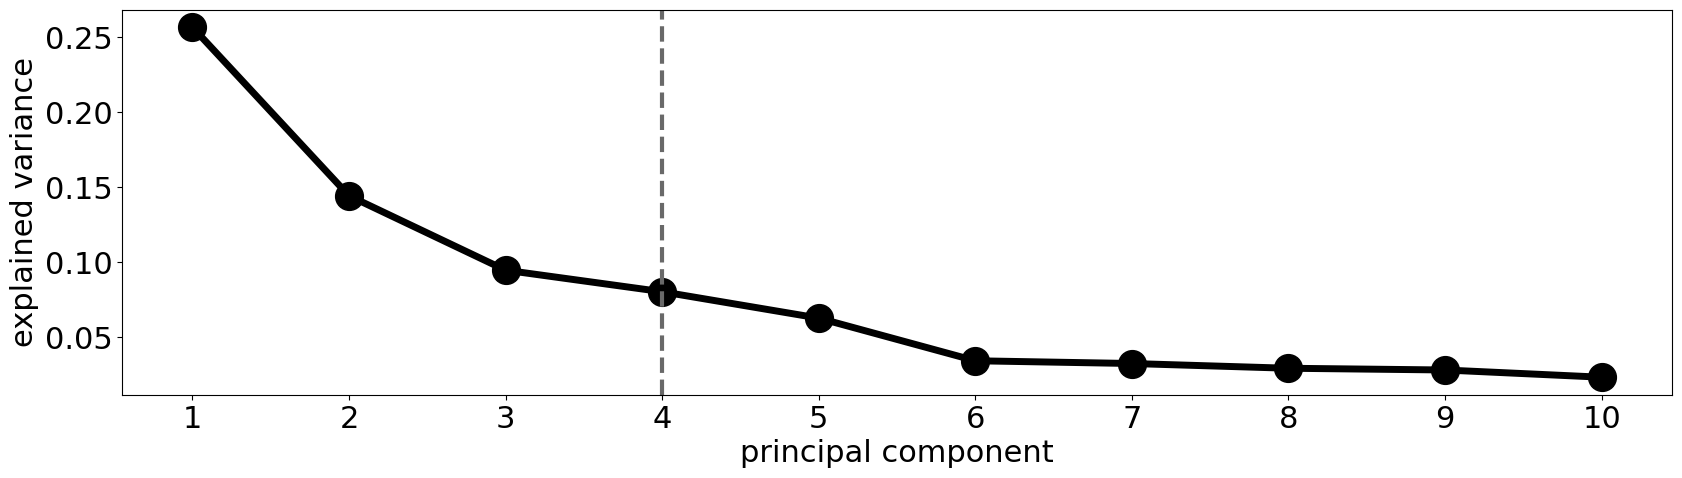

In [ ]:
fs = 22
f, ax = plt.subplots(figsize=(20, 5))
ax.plot(range(1, corr_diff_arr.shape[1])[:10], pca.explained_variance_ratio_[:10], 'ko-', linewidth = 5, markersize=20)
_ = ax.set_xticks(range(1, corr_diff_arr.shape[1])[:10], rotation=90)
ax.axvline(x = 4, color='dimgrey', linestyle='--', linewidth=3)
ax.tick_params(labelsize=fs)
ax.set_ylabel('explained variance', fontsize=fs)
ax.set_xlabel('principal component', fontsize=fs )

In [ ]:
pca.explained_variance_ratio_[:4].sum()

0.5763029230488317

### Permutation

In [ ]:
def _permute(_ser, seed):
    random.seed(seed + _ser.name[0])
    return np.array(random.sample(_ser.values.tolist(), len(_ser.values)))

merged_corr_diff_p = merged_corr_diff.fillna(0).set_index(['cell_type_pd', 'cell_type_ad'], append=True).apply(_permute, seed=0, axis=1).fillna(0)
merged_corr_diff_p.head(3)

   cell_type_pd  cell_type_ad
0  Ast           Ast             [0.0023243188938768854, 0.0030212661698008985,...
1  Ast           Ex              [-0.0194199637457457, 0.06415371569824029, -0....
2  Ast           In              [0.006658564462903053, 0.007223407541807239, -...
dtype: object

In [ ]:
def get_ex_var(merged_corr_diff_p):
    corr_diff_arr = np.stack(merged_corr_diff_p.fillna(0).values).T
    pca = PCA(n_components=corr_diff_arr.shape[1])
    pca.fit(corr_diff_arr)
    return pca.explained_variance_ratio_

def _permute(_ser, seed):
    random.seed(seed + _ser.name[0])
    return np.array(random.sample(_ser.values.tolist(), len(_ser.values)))

def do_permutation(df, idx):
    df_p = df.fillna(0).set_index(['cell_type_pd', 'cell_type_ad'], append=True).apply(_permute, seed=idx, axis=1)
    return get_ex_var(df_p)

ex_vars = np.stack(Parallel(n_jobs = -1, verbose=10)(delayed(do_permutation)(merged_corr_diff, idx) for idx in range(100))).T

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1940s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1266s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  54 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  92 out of 100 | elapsed:    0.6s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.7s finished


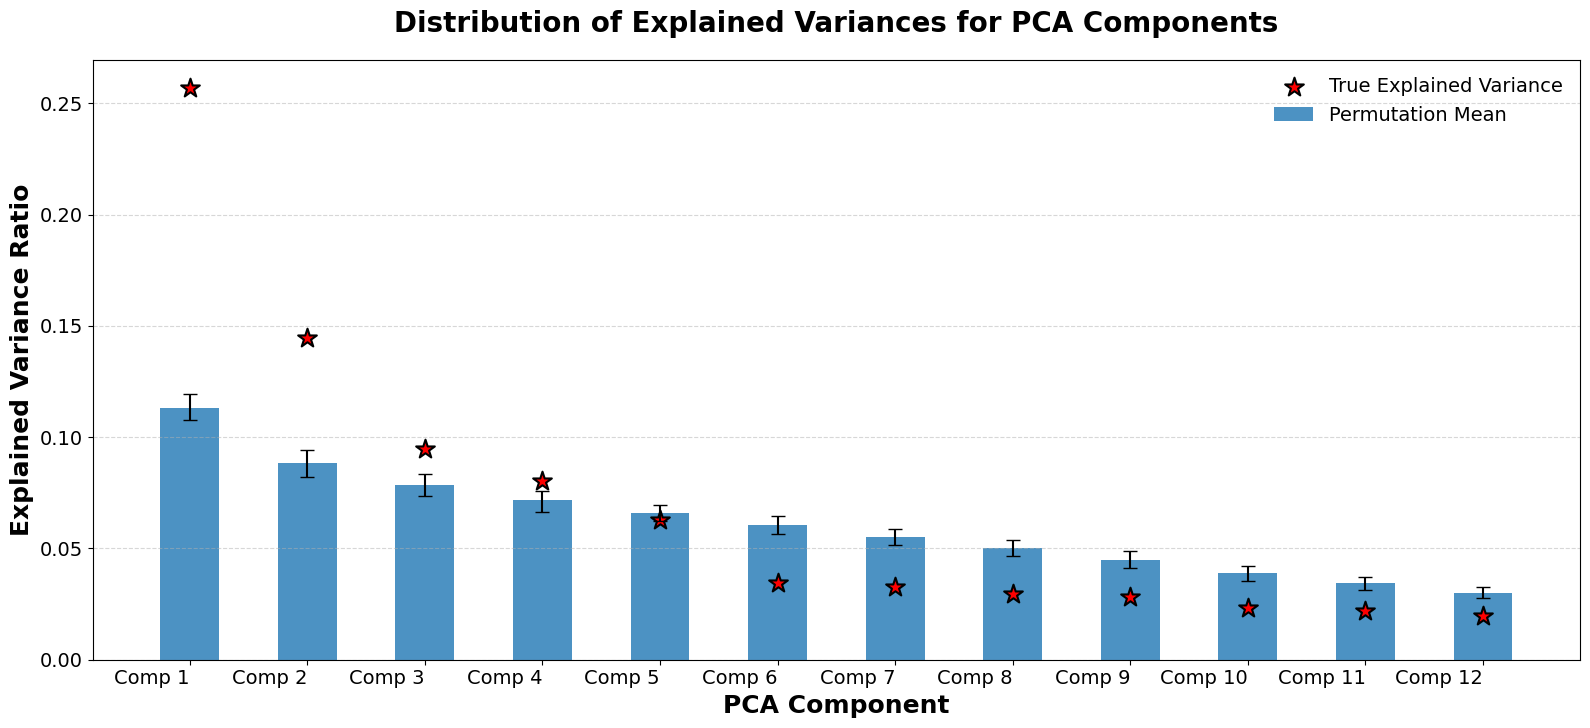

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming ex_vars is a numpy array of shape (54, 100) and pca is a trained PCA model
n_components = 12  # Number of PCA components to include in the plot

# Set up the figure
fig, ax = plt.subplots(figsize=(16, 8))

# Parameters for plot
bar_width = 0.5
index = np.arange(n_components)

means = []
lower_ci = []
upper_ci = []

for i in range(n_components):
    component_data = ex_vars[i]
    mean_val = np.mean(component_data)
    lower = np.percentile(component_data, 5)
    upper = np.percentile(component_data, 95)

    means.append(mean_val)
    lower_ci.append(lower)
    upper_ci.append(upper)

# Convert error bars for plotting (difference between mean and percentile)
errors = [np.array(means) - np.array(lower_ci), np.array(upper_ci) - np.array(means)]

# Plot bars with error bars
ax.bar(index, means, bar_width, color='#1f77b4', alpha=0.8, label='Permutation Mean', yerr=errors, 
       capsize=5, ecolor='black', error_kw={'elinewidth': 1.5})

# Plot the true explained variance for each component
true_values = pca.explained_variance_ratio_[:n_components]
ax.scatter(index, true_values, color='red', marker='*', s=200, edgecolor='black', linewidth=1.5, label='True Explained Variance')

# Formatting the plot
ax.set_xlabel('PCA Component', fontsize=18, fontweight='bold')
ax.set_ylabel('Explained Variance Ratio', fontsize=18, fontweight='bold')
ax.set_title('Distribution of Explained Variances for PCA Components', fontsize=20, fontweight='bold', pad=20)
ax.set_xticks(index)
ax.set_xticklabels([f'Comp {i+1}' for i in range(n_components)], fontsize=14, rotation=0, ha='right')
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=14, loc='upper right', frameon=False)

# Adding gridlines
ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5)

# Tighten layout and add margins to avoid cut-off text
fig.tight_layout()
fig.subplots_adjust(top=0.9, bottom=0.15)

# Show the plot
plt.show()


### Bootstrap samples: stability analysis

In [ ]:
def cosine_similarity(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)
    similarity = dot_product / (norm_vector1 * norm_vector2)
    return similarity

def get_bs_components(pca_comp, pca_orig, n_comps = None):
    n_comps = n_comps if n_comps else pca_comp.shape[0]
    similarity_matrix = []
    for pca_comp_orig in range(n_comps):
        _sm = []
        v1 = pca_orig.components_[pca_comp_orig]
        for pca_comp_idx in range(n_comps):
            _sm.append(abs(cosine_similarity(v1, pca_comp[pca_comp_idx])))
        similarity_matrix.append(_sm)
    return linear_sum_assignment(np.array(similarity_matrix), maximize = True)[1]   #returns the col index

In [ ]:
def _bootstrap_samples(df, rs):
    return df.sample(frac=1, replace=True, random_state = rs)

def _pca_comps(arr, n_comps = None):
    n_comps = n_comps if n_comps else arr.shape[1]
    pca = PCA(n_components=n_comps)
    pca.fit(arr)
    return pca.components_

def get_pca_comps(corr_df, iter, seed, n_comps=None):
    bs_df = _bootstrap_samples(corr_df.set_index(['cell_type_pd', 'cell_type_ad']).T, iter+seed)
    return _pca_comps(bs_df.values, n_comps)

def pca_ctpair_loadings(pca_comps, corr_df):
    corr_df.loc[:, 'celltype_pair'] = corr_df.cell_type_pd.astype(str) + '_' + corr_df.cell_type_ad.astype(str)
    return dict(zip(corr_df['celltype_pair'].values, pca_comps))
    
def do_bs_pcas(corr_df, pca_orig, num_iter = 10, seed = 0, n_comps=None):
    pca_bs_comps = [get_pca_comps(corr_df, iter, seed, n_comps) for iter in range(num_iter)]
    ############################################
    # list of dicts, len of list is number of components, elements of dict are list of loadings from bs for cell-type pairs.
    ############################################
    pca_ctpair_comp = [{} for _ in range(len(pca_bs_comps[0]))]
    for pca_comp in pca_bs_comps:
        # print(pca_comp.shape)
        reorder_idx = get_bs_components(pca_comp, pca_orig, n_comps)
        for pca_comp_idx in range(len(pca_comp)):
            reordered_idx = reorder_idx[pca_comp_idx]
            reflection_invaraince_sign = np.sign(pearsonr(pca_orig.components_[pca_comp_idx], pca_comp[reordered_idx]).statistic)
            _pca_dict = pca_ctpair_loadings(pca_comp[reordered_idx] * reflection_invaraince_sign, corr_df)
            [pca_ctpair_comp[reordered_idx].setdefault(_d[0], []).append(_d[1]) for _d in _pca_dict.items()]
    return pca_ctpair_comp

n_comps = 6
n_bs = 10000
bs_pcas = do_bs_pcas(merged_corr_diff.fillna(0), pca_orig, num_iter = n_bs, n_comps=n_comps)

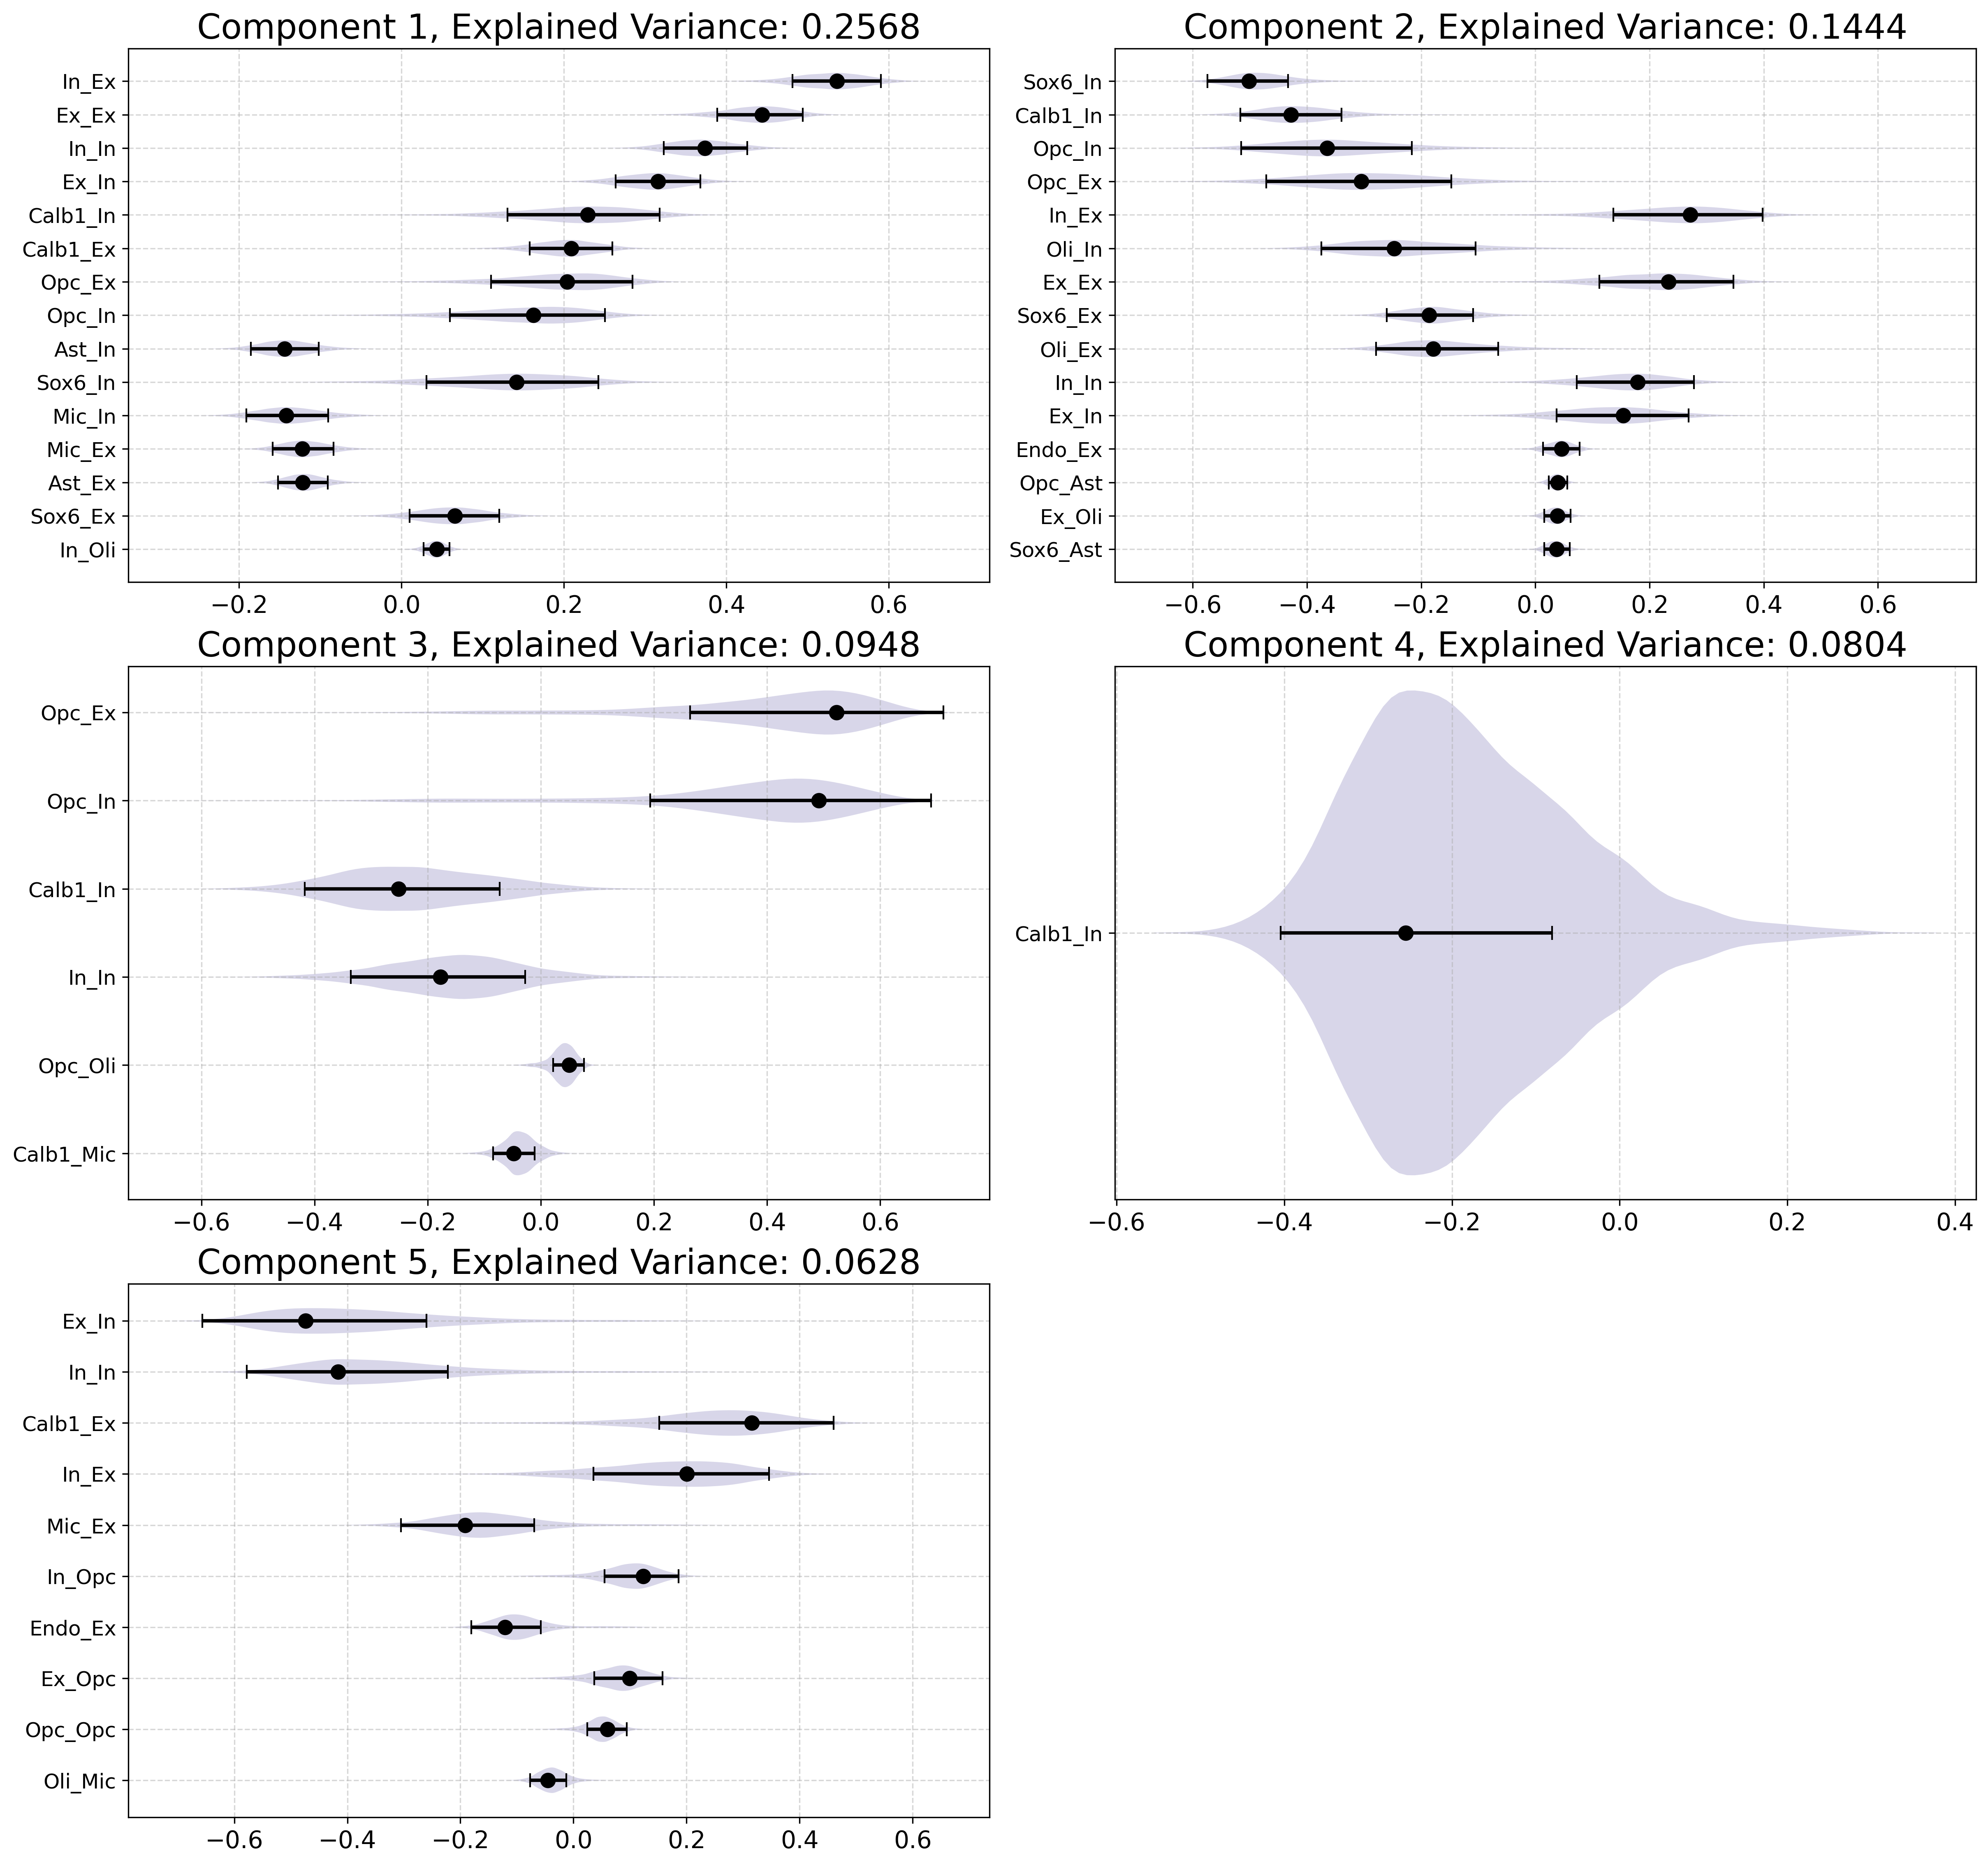

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

# Professional Plot Style
plt.rcParams.update({
    'font.size': 18, 
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'font.family': 'sans-serif',
    'figure.constrained_layout.use': True,
})

n_comps = 6
ncols = 2
nrows = (n_comps + 1) // ncols
num_pairs = 15
fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows), dpi=300)
per_range = 20

for pca_comp in range(n_comps):
    ax = axs[pca_comp // ncols][pca_comp % ncols]  # Adjusted for row/column indexing
    sort_idx = abs(pca.components_[pca_comp]).argsort()[::-1]
    
    df = merged_corr_diff.iloc[sort_idx].copy()
    df.loc[:, 'celltype_pair'] = df.cell_type_pd.astype(str) + '_' + df.cell_type_ad.astype(str)
    
    y_val = np.array([bs_pcas[pca_comp][key] for key in df['celltype_pair'].values]).mean(axis=1)
    xerr_h = stats.scoreatpercentile(np.array([bs_pcas[pca_comp][key] for key in df['celltype_pair'].values]),
                                     100 - per_range / 2, axis=1) - y_val
    xerr_l = y_val - stats.scoreatpercentile(np.array([bs_pcas[pca_comp][key] for key in df['celltype_pair'].values]),
                                             per_range / 2, axis=1)

    keep_idxs = np.where(np.multiply(xerr_h + y_val, y_val - xerr_l) > 0)[0]
    if keep_idxs.shape[0] == 0:
        ax.axis("off")
        continue

    # Violin plot with clean styling
    bs_vals = np.array([bs_pcas[pca_comp][key] for key in df['celltype_pair'].values])[keep_idxs][:num_pairs][::-1].T
    violin_parts = ax.violinplot(bs_vals, np.arange(bs_vals.shape[1]), vert=False, showextrema=False)
    for pc in violin_parts['bodies']:
        pc.set_facecolor(sns.color_palette("Purples", as_cmap=True)(0.5))
        pc.set_edgecolor('none')
        pc.set_alpha(0.4)
    
    # Error bars
    reversed_indices = np.arange(len(keep_idxs[:num_pairs]))[::-1]
    ax.errorbar(x=pca_orig.components_[pca_comp][sort_idx][keep_idxs][:num_pairs][::-1],
                y=np.arange(len(keep_idxs[:num_pairs])),
                xerr=np.vstack([xerr_l[keep_idxs][:num_pairs][::-1], xerr_h[keep_idxs][:num_pairs][::-1]]),
                fmt='none', elinewidth=2, capsize=4, ecolor='black')

    # Mean data points as dots
    ax.plot(pca_orig.components_[pca_comp][sort_idx][keep_idxs][:num_pairs],
            reversed_indices,
            'o', markersize=8, color='black')
    # ax.plot(pca_orig.components_[pca_comp][sort_idx][keep_idxs][:num_pairs], 
    #         df['celltype_pair'].values[keep_idxs][:num_pairs][::-1],'o', markersize=8, color='black')

    # Styling the axes
    ax.set_yticks(np.arange(len(keep_idxs[:num_pairs])))
    ax.set_yticklabels(df['celltype_pair'].values[keep_idxs][:num_pairs][::-1], fontsize=12)
    ax.set_title(f'Component {pca_comp+1}, Explained Variance: {pca_orig.explained_variance_ratio_[pca_comp]:.4f}')
    ax.grid(True, linestyle='--', alpha=0.5)

# Hide empty subplots
for i in range(n_comps, nrows * ncols):
    fig.delaxes(axs.flat[i])

# Save or show
plt.tight_layout()
plt.show()
fig.savefig('../NeuroOverlap/manuscript/main figures/DGCN_bs.svg')


## PLS-DA vs differential gene co-expression network
Comparison of PLS-DA with DGCN results

In [ ]:
import sys
sys.path.append('../AMD')
import correlation_base as co

In [ ]:
corr_metric = kendalltau

In [ ]:
def do_all_corrs(disease1, disease2, goi, label, corr_metric):
    try:
        label = 'disease'
        df1_d = pd.read_csv(gna_prefix+f'GeneCorrs/{disease1}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv', index_col=0)
        df1_dp = pd.read_csv(gna_prefix+f'GeneCorrs/{disease1}_agg_df_{goi}_{label}_{corr_metric.__name__}_pval.csv', index_col=0)
        # df2_d = pd.read_csv(gna_prefix+f'GeneCorrs/{disease2}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv', index_col=0)
        # df2_dp = pd.read_csv(gna_prefix+f'GeneCorrs/{disease2}_agg_df_{goi}_{label}_{corr_metric.__name__}_pval.csv', index_col=0)

        label = 'control'
        df1_c = pd.read_csv(gna_prefix+f'GeneCorrs/{disease1}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv', index_col=0)
        df1_cp = pd.read_csv(gna_prefix+f'GeneCorrs/{disease1}_agg_df_{goi}_{label}_{corr_metric.__name__}_pval.csv', index_col=0)
        # df2_c = pd.read_csv(gna_prefix+f'GeneCorrs/{disease2}_agg_df_{goi}_{label}_{corr_metric.__name__}.csv', index_col=0)
        # df2_cp = pd.read_csv(gna_prefix+f'GeneCorrs/{disease2}_agg_df_{goi}_{label}_{corr_metric.__name__}_pval.csv', index_col=0)
        # return  df1_d, df1_c, df2_d, df2_c
        return df1_d, df1_dp, df1_c, df1_cp
    except:
        print(f'skipping {goi} because the gene is not present in one of the diseases')
        return pd.DataFrame() #0
    
df_diff = Parallel(n_jobs=-1, verbose=10)(delayed(do_all_corrs)('ad', 'ad', goi, 'disease', corr_metric) for goi in all_gois)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


skipping TRIM40 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    4.9s


skipping LINC00326 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    5.5s


...

[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 108 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-1)]: Done 125 tasks      | elapsed:   20.1s


skipping LZTS3 because the gene is not present in one of the diseases


[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:   22.6s


skipping EGFR because the gene is not present in one of the diseases
skipping MAPT because the gene is not present in one of the diseases
skipping MAF because the gene is not present in one of the diseases
skipping SORL1 because the gene is not present in one of the diseases
skipping CCDC62 because the gene is not present in one of the diseases
skipping SLC2A4RG because the gene is not present in one of the diseases
skipping ITGA8 because the gene is not present in one of the diseases
skipping ELOVL7 because the gene is not present in one of the diseases
skipping ABI3 because the gene is not present in one of the diseases
skipping MCCC1 because the gene is not present in one of the diseases
skipping SNCA because the gene is not present in one of the diseases
skipping SMAD4 because the gene is not present in one of the diseases
skipping PMVK because the gene is not present in one of the diseases
skipping NCKAP5L because the gene is not present in one of the diseases
skipping RAB25 becau

[Parallel(n_jobs=-1)]: Done 175 out of 175 | elapsed:   24.6s finished


In [ ]:
loadings_ad = co.CorrelationBase.read_zip_to_dict('../OverlapAnalysis_thor_pmi_adj/AD/Rosmap/DEGenes/pls_500bs_5thresh_42seed_thresholded_97_5highper_2_5lowper_labelpermutefactor.zip')
loadings_pd = co.CorrelationBase.read_zip_to_dict('../OverlapAnalysis_thor_pmi_adj/PD/Kam/DEGenes/pls_500bs_5thresh_42seed_thresholded_97_5highper_2_5lowper_labelpermutefactor.zip')

In [ ]:
overlap_dict = {}
custom_ct_order_pd = ['Excitatory neuron', 'Inhibitory neuron', 'Astrocyte', 'Microglia', 'OPC', 'Oligodendrocyte', 'CALB1', 'SOX6', 'Endothelial']
custom_ct_order_ad = ['Ex','In', 'Oli',  'Mic', 'Ast','Opc', ]

for idx, goi in enumerate(all_gois):
    print('INDEX: ', idx)
    if len(df_diff[idx])==0:
        continue
    df2_d, df2_dp, df2_c, df2_cp = df_diff[idx]
    df2_d_bh = pd.DataFrame()
    for corr_df, pval_df in zip(df2_d.iterrows(), df2_dp.iterrows()):
        ct = corr_df[0]
        pval_df = pval_df[1].to_frame()
        pval_df['fdr_bh'] = multipletests(pval_df[ct].values, method='fdr_bh')[1]
        pval_df.drop(pval_df[pval_df.fdr_bh>pval_ct].index, inplace=True) 
        _df = corr_df[1].to_frame().join(pval_df['fdr_bh'], how = 'inner')
        df2_d_bh = df2_d_bh.join( _df[ct], how = 'outer' )

    df2_d_bh.fillna(0, inplace = True)

    df2_c_bh = pd.DataFrame()
    for corr_df, pval_df in zip(df2_c.iterrows(), df2_cp.iterrows()):
        ct = corr_df[0]
        pval_df = pval_df[1].to_frame()
        pval_df['fdr_bh'] = multipletests(pval_df[ct].values, method='fdr_bh')[1]
        pval_df.drop(pval_df[pval_df.fdr_bh>pval_ct].index, inplace=True)
        _df = corr_df[1].to_frame().join(pval_df['fdr_bh'], how = 'inner')
        df2_c_bh = df2_c_bh.join( _df[ct], how = 'outer' )

    df2_c_bh.fillna(0, inplace = True)
    _df_do = df2_d_bh.T.reset_index(names=['cell_type'])
    _df_co = df2_c_bh.T.reset_index(names=['cell_type'])
    
    for ct in _df_do.cell_type.unique():
        overlap_dict.setdefault(ct, {})
        overlap_dict[ct][goi] = {}
        _df_d = _df_do[_df_do.cell_type==ct]
        _df_c = _df_co[_df_co.cell_type==ct]
        _df_d = _df_d[_df_d!=0].dropna(axis=1).set_index('cell_type').T
        _df_d.index.name='genes'
        _df_c = _df_c[_df_c!=0].dropna(axis=1).set_index('cell_type').T
        _df_c.index.name='genes'

        _df = _df_d.merge(_df_c, left_index=True, right_index=True, suffixes = ['_d', '_c'])
        _df[ct] = _df[f'{ct}_d'] - _df[f'{ct}_c'] # PErforming differential
        _df_abs = _df[[ct]].abs().sort_values(by=ct, ascending=False)
        if _df_abs.empty:
            continue
        _df_abs.loc[_df_abs[ct] < np.percentile(_df_abs.values, [99])[0], ct] = 0
        codev_genes = _df_abs[_df_abs[ct]!=0].index #_df_abs[_df_abs.Mic>0.05].sort_values('Mic', ascending=False).index
        
        for ct2 in custom_ct_order_ad: #loadings_pd.keys():
            _pls_df = loadings_ad[ct2].copy()
            for component in _pls_df.component.unique():
                plsl = _pls_df[(_pls_df.component==component)]
                plsl.set_index('gene', inplace=True)
                _tdf = _df_abs.join(plsl['loading'], how = 'inner')
                
                pls_genes = plsl[plsl.loading!=0].index.unique()
                set_overlap = set(codev_genes).intersection(set(pls_genes))
                set_union = set(codev_genes).union(set(pls_genes))
                # if set_union:
                metric = len(set_overlap)/(len(codev_genes)+1e-5)
                overlap_dict[ct][goi].update({f'{ct2} {component+1}': metric})
                

In [ ]:
df2_d, df2_dp, df2_c, df2_cp = df_diff[0]

In [ ]:
pval_ct = 0.01

In [ ]:
# Disease DGCN
df2_d_bh = pd.DataFrame()
for corr_df, pval_df in zip(df2_d.iterrows(), df2_dp.iterrows()):
    ct = corr_df[0]
    pval_df = pval_df[1].to_frame()
    pval_df['fdr_bh'] = multipletests(pval_df[ct].values, method='fdr_bh')[1]
    pval_df.drop(pval_df[pval_df.fdr_bh>pval_ct].index, inplace=True)
    _df = corr_df[1].to_frame().join(pval_df['fdr_bh'], how = 'inner')
    df2_d_bh = df2_d_bh.join( _df[ct], how = 'outer' )

df2_d_bh.fillna(0, inplace = True)


In [ ]:
# Control DGCN
df2_c_bh = pd.DataFrame()
for corr_df, pval_df in zip(df2_c.iterrows(), df2_cp.iterrows()):
    ct = corr_df[0]
    pval_df = pval_df[1].to_frame()
    pval_df['fdr_bh'] = multipletests(pval_df[ct].values, method='fdr_bh')[1]
    pval_df.drop(pval_df[pval_df.fdr_bh>pval_ct].index, inplace=True)
    _df = corr_df[1].to_frame().join(pval_df['fdr_bh'], how = 'inner')
    df2_c_bh = df2_c_bh.join( _df[ct], how = 'outer' )

df2_c_bh.fillna(0, inplace = True)

In [ ]:
all_df = pd.DataFrame()
for ct in ['Ex', 'In', 'Oli', 'Mic', 'Ast', 'Opc']:
    if ct not in ['Macrophage', 'Ependyma']:
        _df = pd.DataFrame.from_dict(overlap_dict[ct]).T
        _df['ct'] = ct
        _df.index.name = 'pls_ct'
        _df.set_index('ct', append = True, inplace = True)
        all_df = pd.concat([all_df, _df])

# all_df.to_csv(gna_prefix + 'PD_dgcn_pls.csv')

In [ ]:
all_df = pd.read_csv(gna_prefix + 'PD_dgcn_pls.csv')

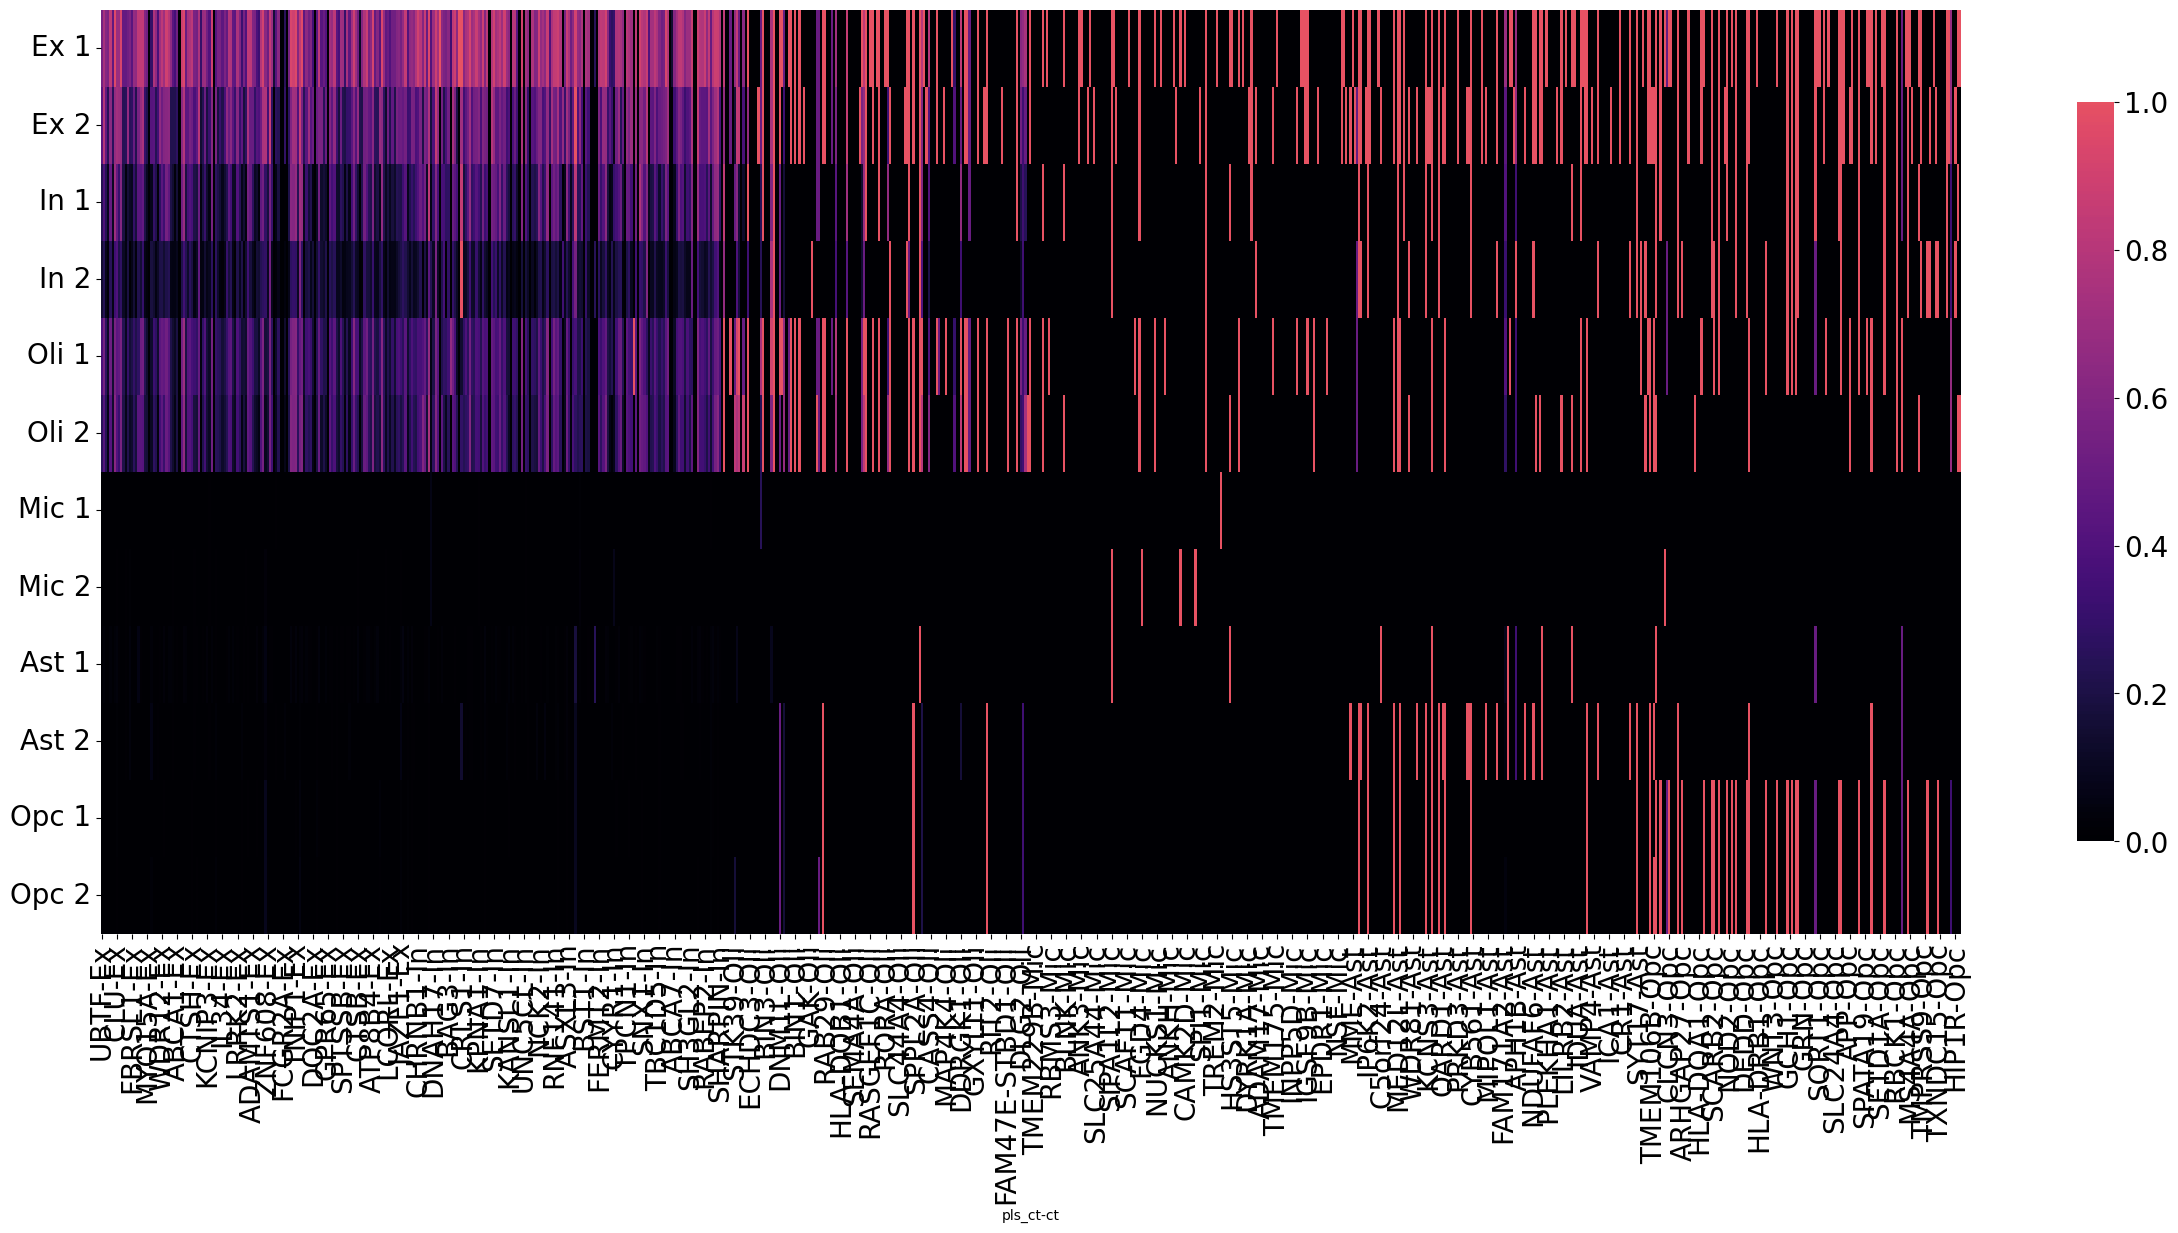

In [ ]:
f, ax = plt.subplots(figsize=(30,12))
fs = 20
cmap = sns.heatmap(all_df.T.abs().fillna(0), ax = ax, cbar_kws={'shrink':0.8}, cmap = 'magma', center = 0.8, vmax = 1)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=fs)
ax.tick_params(axis='y', rotation = 0, labelsize = fs)
ax.tick_params(axis = 'x', rotation = 90, labelsize = fs)